# COMP447 Colab First Run

**Goal:** Get ECT running on a Colab T4, verify environment, do a dry-run, and launch the first sanity training.

**Runtime:** Must be **T4 GPU** (Runtime > Change runtime type > T4 GPU in browser Colab, or select T4 when connecting from VS Code Colab extension).

**How to use with AI assistance:** Run each cell, wait for output. If a cell fails, the error is saved into this `.ipynb` file and Claude can read it directly from the repo. No copy-paste needed.

---

## Cell 1: Verify GPU

**Expected output:**
```
torch: 2.x.x+cu...
cuda available: True
gpu: Tesla T4
```

If `cuda available: False` → runtime is not T4. Change runtime type and reconnect.
If gpu is not T4 (e.g. `L4`, `A100`) → still OK for dry run, but final latency numbers must come from T4.

In [1]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("vram gb:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
vram gb: 102.0


## Cell 2: (skipped) Drive mount — known issue with VS Code extension

**Known issue:** `drive.mount('/content/drive')` fails from the VS Code Colab extension with `MessageError: [dfs_ephemeral] Credentials propagation unsuccessful`. The extension uses its own OAuth flow, incompatible with the inline mount.

**Workaround for today:** skip Drive entirely. Outputs stay in `/content` during the session. For the Monday sanity run this is fine — if the session dies we re-run.

**If you want Drive later:** Command Palette → `Colab: Mount Google Drive to Server...` — this inserts a snippet that uses the extension's own auth and works. Or fall back to browser Colab for runs that need persistence.

The cell below is now a no-op placeholder.

In [2]:
# Drive mount skipped — see markdown above for reason.
# Outputs will live in /content for this session.
import os
os.makedirs("/content/COMP447_runs", exist_ok=True)
print("drive mount skipped, local output dir ready:", "/content/COMP447_runs")

drive mount skipped, local output dir ready: /content/COMP447_runs


## Cell 3: Clone the COMP447 wrapper repo

**Expected output:** listing showing `project`, `final_upload`, `readings`, `proposal_template`, `README.md`.

Note: this is only the wrapper repo. ECT and EDM are cloned fresh in the next cell by `setup_ect.sh`. That's why this clone is fast.

In [3]:
%cd /content
!rm -rf COMP447
!git clone https://github.com/bakaraman/COMP447.git
%cd /content/COMP447
!ls

/content
Cloning into 'COMP447'...
remote: Enumerating objects: 487, done.
remote: Counting objects: 100% (405/405), done.
remote: Compressing objects: 100% (385/385), done.
remote: Total 487 (delta 26), reused 394 (delta 17), pack-reused 82 (from 1)
Receiving objects: 100% (487/487), 131.69 MiB | 51.49 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/COMP447
final_upload  project  proposal_template  readings  README.md


## Cell 4: Clone ECT and EDM upstream repos

**Expected output:** two `Cloning into ...` messages, then `Bootstrap complete.` and the "Next steps" block.

This runs `project/scripts/setup_ect.sh` which clones:
- `https://github.com/locuslab/ect.git` into `project/src/ect`
- `https://github.com/NVlabs/edm.git` into `project/src/edm`

In [4]:
%cd /content/COMP447
!bash project/scripts/setup_ect.sh

/content/COMP447
Repo root: /content/COMP447

Cloning or refreshing ECT...
Cloning into '/content/COMP447/project/src/ect'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 123 (delta 65), reused 96 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 823.47 KiB | 7.04 MiB/s, done.
Resolving deltas: 100% (65/65), done.
  patched: InfiniteSampler.__init__ for torch >= 2.2

Cloning or refreshing EDM...
Cloning into '/content/COMP447/project/src/edm'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 54 (delta 13), reused 9 (delta 9), pack-reused 19 (from 1)
Receiving objects: 100% (54/54), 2.13 MiB | 14.04 MiB/s, done.
Resolving deltas: 100% (13/13), done.

Bootstrap complete.

Next steps:
  1. Create the runtime environment shown in:
     - /content/COMP447/project/src/

## Cell 5: Install missing Python packages

**Expected output:** a short pip install log, no errors. Colab already has torch, numpy, scipy, pillow, tqdm preinstalled, so this only fills in the rest.

If `diffusers==0.26.3` or `accelerate==0.27.2` pins conflict with Colab's preinstalled versions, we'll relax them — report back.

In [5]:
!pip install -q psutil click requests pyspng imageio-ffmpeg diffusers==0.26.3 accelerate==0.27.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 23.6 MB/s eta 0:00:00


## Cell 6: Prepare CIFAR-10 in EDM format

**Expected output:**
- `cifar-10-python.tar.gz` downloaded (~170 MB)
- `datasets/cifar10-32x32.zip` created (~180 MB)
- Final `ls -lh datasets` shows the zip

`dataset_tool.py` converts the raw CIFAR to the EDM/ECT training format (zipped uint8 images + labels).

In [6]:
%cd /content/COMP447/project/src/ect
!mkdir -p datasets
!wget -nc -q --show-progress -O /content/cifar-10-python.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!python3 dataset_tool.py --source=/content/cifar-10-python.tar.gz --dest=datasets/cifar10-32x32.zip
!ls -lh datasets

/content/COMP447/project/src/ect
/content/cifar-10-p 100%[===================>] 162.60M  53.3MB/s    in 3.1s    
  0% 0/50000 [00:00<?, ?it/s]/content/COMP447/project/src/ect/dataset_tool.py:425: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = PIL.Image.fromarray(img, {1: 'L', 3: 'RGB'}[channels])
100% 50000/50000 [00:04<00:00, 10905.13it/s]
total 159M
-rw-r--r-- 1 root root 159M Apr 20 17:35 cifar10-32x32.zip


## Cell 7: Import smoke test

**Expected output:** `psutil ok`, `torch ok`, `cuda: True`, no ImportError.

This verifies that the packages ECT needs at import time are all present in the current kernel.

In [7]:
import sys, importlib
for pkg in ["psutil", "torch", "click", "PIL", "numpy", "scipy", "tqdm", "imageio", "pyspng"]:
    try:
        importlib.import_module(pkg)
        print(f"  ok  {pkg}")
    except ImportError as e:
        print(f"  MISSING  {pkg}: {e}")
import torch
print(f"\npython: {sys.version.split()[0]}")
print(f"torch:  {torch.__version__}")
print(f"cuda:   {torch.cuda.is_available()}")

  ok  psutil
  ok  torch
  ok  click
  ok  PIL
  ok  numpy
  ok  scipy
  ok  tqdm
  ok  imageio
  ok  pyspng

python: 3.12.13
torch:  2.10.0+cu128
cuda:   True


## Cell 8: Dry-run the ECT training command

**Expected output:** ECT parses training options, `dist.init()` initializes with WORLD_SIZE=1, prints the training config JSON, then exits because of `-n` / `--dry_run`. No traceback.

**Why torchrun, not `python3`:** `ct_train.py` calls `dist.init()` which invokes `torch.distributed.init_process_group(init_method='env://')`. That requires MASTER_ADDR, MASTER_PORT, RANK, WORLD_SIZE env vars. `torchrun` sets those automatically for single-process single-node runs. Calling plain `python3` would fail inside `init_process_group`.

**If it still fails, usual suspects:**
- pretrained checkpoint 404 / timeout → retry
- `diffusers==0.26.3` version conflict with torch 2.10 → we'll relax the pin
- NCCL backend errors on single-GPU → unlikely but we'd switch to `gloo`

In [8]:
%cd /content/COMP447/project/src/ect
!torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29501 \
  ct_train.py \
    --outdir=ct-runs-dry \
    --data=datasets/cifar10-32x32.zip \
    --cond=0 \
    --arch=ddpmpp \
    --metrics=fid50k_full \
    --transfer=https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl \
    --duration=0.001 \
    --batch=8 \
    --dry_run

/content/COMP447/project/src/ect

Training options:
{
  "dataset_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "datasets/cifar10-32x32.zip",
    "use_labels": false,
    "xflip": false,
    "cache": true,
    "resolution": 32,
    "max_size": 50000
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 1,
    "prefetch_factor": 2
  },
  "network_kwargs": {
    "model_type": "SongUNet",
    "embedding_type": "positional",
    "encoder_type": "standard",
    "decoder_type": "standard",
    "channel_mult_noise": 1,
    "resample_filter": [
      1,
      1
    ],
    "model_channels": 128,
    "channel_mult": [
      2,
      2,
      2
    ],
    "class_name": "training.networks.ECMPrecond",
    "augment_dim": 9,
    "dropout": 0.13,
    "use_fp16": false
  },
  "loss_kwargs": {
    "P_mean": -1.1,
    "P_std": 2.0,
    "q": 2.0,
    "c": 0.0,
    "k": 8.0,
    "b": 1.0,
    "adj": "sigmoid",
    "class_name": "training.loss.ECMLoss"
 

## Cell 8b: Mini training sanity (2-3 minutes)

**Why this cell exists:** Cell 8 (dry run) only validates config parsing and network instantiation. It does **not** run a single training step. This cell runs a few real forward+backward passes so we know:

- pretrained EDM checkpoint actually downloads and loads into the network
- the ECT loss is finite on T4 (not NaN)
- batch 64 fits in 16 GB VRAM (ECT's default batch=128 might OOM)
- torch 2.10 / cuda 12.8 / diffusers 0.26 all agree numerically

**Config:**
- `--duration=0.02` → total 20 kimg (vs Cell 9's 25,600 kimg)
- `--batch=64` → half of ECT default, safe on T4
- `--tick=1` → print a tick line every 1 kimg, so you see ~20 tick logs
- `--eval_every=1000000` + `--dump=1000000` → no FID / snapshot during mini run

**Expected output:** `Loading training set...`, `Constructing network...`, `Setting up EMA...`, then 1-20 `tick N ... kimg X ... loss Y ...` lines with finite loss, then clean exit. Total wall ~2-4 min.

**If the loss is NaN or you see CUDA OOM:** stop and report. We drop batch to 32 or enable mixed precision.

In [9]:
%cd /content/COMP447/project/src/ect

# Patch 1: ECT's InfiniteSampler is incompatible with torch >= 2.2
# torch.utils.data.Sampler.__init__ no longer takes data_source arg.
# Fixes: TypeError: object.__init__() takes exactly one argument
!sed -i 's|super().__init__(dataset)|super().__init__()|' torch_utils/misc.py
!grep -n "super().__init__" torch_utils/misc.py

# NOTE: --metrics=none disables the end-of-training FID50k evaluation which
# takes 5-15 min on T4 and is not needed for a 20-kimg sanity. The 20 ticks
# of training are what we're validating here, not FID quality.
!torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29502 \
  ct_train.py \
    --outdir=ct-runs-mini \
    --data=datasets/cifar10-32x32.zip \
    --cond=0 \
    --arch=ddpmpp \
    --precond=ect \
    --metrics=none \
    --transfer=https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl \
    --duration=0.02 \
    --tick=1 \
    --batch=64 \
    --lr=0.0001 \
    --optim=RAdam \
    --dropout=0.2 \
    --augment=0.0 \
    -q 256 \
    --double=10000 \
    --ema_beta=0.9993 \
    --eval_every=1000000 \
    --dump=1000000 \
    --snap=1000000 \
    --desc=mini_sanity

/content/COMP447/project/src/ect
116:        super().__init__()

Training options:
{
  "dataset_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "datasets/cifar10-32x32.zip",
    "use_labels": false,
    "xflip": false,
    "cache": true,
    "resolution": 32,
    "max_size": 50000
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 1,
    "prefetch_factor": 2
  },
  "network_kwargs": {
    "model_type": "SongUNet",
    "embedding_type": "positional",
    "encoder_type": "standard",
    "decoder_type": "standard",
    "channel_mult_noise": 1,
    "resample_filter": [
      1,
      1
    ],
    "model_channels": 128,
    "channel_mult": [
      2,
      2,
      2
    ],
    "class_name": "training.networks.ECMPrecond",
    "dropout": 0.2,
    "use_fp16": false
  },
  "loss_kwargs": {
    "P_mean": -1.1,
    "P_std": 2.0,
    "q": 256.0,
    "c": 0.0,
    "k": 8.0,
    "b": 1.0,
    "adj": "sigmoid",
    "class_name": "training.loss.

## Cell 9: Medium tuning with 4 ablation snapshots (2000 kimg)

Trains ECT for 2000 kimg and saves **4 snapshots** along the way for the tuning-budget ablation:

| Tick | kimg | Snapshot file |
|---|---|---|
| 50 | 500 | `network-snapshot-000050.pkl` |
| 100 | 1000 | `network-snapshot-000100.pkl` |
| 150 | 1500 | `network-snapshot-000150.pkl` |
| 200 | 2000 | `network-snapshot-000200.pkl` |

These 4 files feed Cell 10 (ablation FID eval) and Cell 12 (latency measurements).

**Key change from Cell 8b:** `--snap=50` saves a snapshot every 50 ticks. With `--tick=10`, one snapshot per 500 kimg. Also `--metrics=none` to skip intermediate FID eval (we do this explicitly in Cell 10).

**Expected wall time:**
- G4 / Blackwell: ~15 min
- L4: ~30 min
- T4: ~1.5 hours (use a faster GPU)

**Compute budget:** G4 ~10-12 units, L4 ~2-3 units.

**DO NOT** run on T4 — too slow. Switch runtime before this cell if you're on T4.

In [10]:
%cd /content/COMP447/project/src/ect

# Patch is idempotent — safe to re-run
!sed -i 's|super().__init__(dataset)|super().__init__()|' torch_utils/misc.py

!torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29503 \
  ct_train.py \
    --outdir=ct-runs-medium \
    --data=datasets/cifar10-32x32.zip \
    --cond=0 \
    --arch=ddpmpp \
    --precond=ect \
    --metrics=none \
    --transfer=https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl \
    --duration=2.0 \
    --tick=10 \
    --batch=128 \
    --lr=0.0001 \
    --optim=RAdam \
    --dropout=0.2 \
    --augment=0.0 \
    -q 256 \
    --double=10000 \
    --ema_beta=0.9993 \
    --eval_every=1000000 \
    --dump=1000000 \
    --snap=50 \
    --desc=medium_2k

/content/COMP447/project/src/ect

Training options:
{
  "dataset_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "datasets/cifar10-32x32.zip",
    "use_labels": false,
    "xflip": false,
    "cache": true,
    "resolution": 32,
    "max_size": 50000
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 1,
    "prefetch_factor": 2
  },
  "network_kwargs": {
    "model_type": "SongUNet",
    "embedding_type": "positional",
    "encoder_type": "standard",
    "decoder_type": "standard",
    "channel_mult_noise": 1,
    "resample_filter": [
      1,
      1
    ],
    "model_channels": 128,
    "channel_mult": [
      2,
      2,
      2
    ],
    "class_name": "training.networks.ECMPrecond",
    "dropout": 0.2,
    "use_fp16": false
  },
  "loss_kwargs": {
    "P_mean": -1.1,
    "P_std": 2.0,
    "q": 256.0,
    "c": 0.0,
    "k": 8.0,
    "b": 1.0,
    "adj": "sigmoid",
    "class_name": "training.loss.ECMLoss"
  },
  "optimizer_kwar

## Cell 10: ECT ablation FID evaluation

Runs `ct_eval.py` on each of the 4 snapshots from Cell 9 to get **1-step** and **2-step FID50k** for each training budget (500 / 1000 / 1500 / 2000 kimg).

ECT's eval produces two metrics automatically:
- `fid50k_full` → 1-step generation FID (50,000 samples)
- `two_step_fid50k_full` → 2-step generation FID with default `mid_t=0.821`

**Expected time per snapshot on G4:** ~3-5 min (dominated by 50k sample generation + inception feature extraction).
**Total for 4 snapshots: ~15-20 min.**

**Output:** `project/results/ablation_fid.csv` with columns `kimg, tick, fid_1step, fid_2step, snapshot`.

This is the **tuning-budget ablation data** — feeds the "quality vs training time" curve.

In [11]:
import os, glob, json, subprocess, csv
from pathlib import Path

%cd /content/COMP447/project/src/ect

# Find the most recent medium training run
run_dirs = sorted(glob.glob("ct-runs-medium/*-medium_2k"))
if not run_dirs:
    raise RuntimeError("No ct-runs-medium/*-medium_2k dir found. Run Cell 9 first.")
run_dir = run_dirs[-1]
print(f"Using run dir: {run_dir}")

# Find all snapshots (exclude 'latest')
snapshots = sorted(glob.glob(f"{run_dir}/network-snapshot-*.pkl"))
snapshots = [s for s in snapshots if "latest" not in s]
print(f"Found {len(snapshots)} snapshots: {[Path(s).name for s in snapshots]}\n")

results_dir = Path("/content/COMP447/project/results")
results_dir.mkdir(exist_ok=True, parents=True)

KIMG_PER_TICK = 10  # must match Cell 9's --tick=10

rows = []
for snap in snapshots:
    tick = int(Path(snap).stem.split("-")[-1])
    kimg = tick * KIMG_PER_TICK
    print(f"=== Evaluating snapshot tick {tick} ({kimg} kimg) ===")

    eval_outdir = f"ct-evals/snap-{tick:06d}"

    cmd = [
        "torchrun", "--nnodes=1", "--nproc_per_node=1",
        "--rdzv_backend=c10d", "--rdzv_endpoint=localhost:29510",
        "ct_eval.py",
        "--outdir", eval_outdir,
        "--data", "datasets/cifar10-32x32.zip",
        "--cond=0",
        "--arch=ddpmpp",
        "--precond=ct",
        "--metrics=fid50k_full",
        "--resume", snap,
        "--desc", f"ablation_{kimg}kimg",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("EVAL FAILED. STDERR:", result.stderr[-1500:])
        continue

    # Parse the JSON result lines from stdout
    fid_1step, fid_2step = None, None
    for line in result.stdout.split("\n"):
        line = line.strip()
        if line.startswith("{") and '"metric"' in line and '"results"' in line:
            try:
                d = json.loads(line)
                metric_name = d.get("metric", "")
                fid_val = d.get("results", {}).get("fid50k_full")
                if "two_step" in metric_name:
                    fid_2step = fid_val
                else:
                    fid_1step = fid_val
            except Exception:
                pass

    print(f"  {kimg:5d} kimg: 1-step FID={fid_1step}, 2-step FID={fid_2step}\n")
    rows.append({"kimg": kimg, "tick": tick, "fid_1step": fid_1step, "fid_2step": fid_2step, "snapshot": snap})

csv_path = results_dir / "ablation_fid.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["kimg", "tick", "fid_1step", "fid_2step", "snapshot"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved ablation FID to {csv_path}")
print("\n=== Summary ===")
for r in rows:
    if r["fid_1step"] is None and r["fid_2step"] is None:
        print(f"  {r['kimg']:5d} kimg: evaluation failed")
    else:
        f1 = f"{r['fid_1step']:.2f}" if r["fid_1step"] is not None else "—"
        f2 = f"{r['fid_2step']:.2f}" if r["fid_2step"] is not None else "—"
        print(f"  {r['kimg']:5d} kimg: 1-step FID {f1} / 2-step FID {f2}")

/content/COMP447/project/src/ect
Using run dir: ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k
Found 4 snapshots: ['network-snapshot-000050.pkl', 'network-snapshot-000100.pkl', 'network-snapshot-000150.pkl', 'network-snapshot-000198.pkl']

=== Evaluating snapshot tick 50 (500 kimg) ===
    500 kimg: 1-step FID=8.135476124822045, 2-step FID=None

=== Evaluating snapshot tick 100 (1000 kimg) ===
   1000 kimg: 1-step FID=2.7730464596706557, 2-step FID=None

=== Evaluating snapshot tick 150 (1500 kimg) ===
   1500 kimg: 1-step FID=2.7021001419223447, 2-step FID=None

=== Evaluating snapshot tick 198 (1980 kimg) ===
   1980 kimg: 1-step FID=2.446277615255744, 2-step FID=None


✓ Saved ablation FID to /content/COMP447/project/results/ablation_fid.csv

=== Summary ===
    500 kimg: 1-step FID 8.14 / 2-step FID —
   1000 kimg: 1-step FID 2.77 / 2-step FID —
   1500 kimg: 1-step FID 2.70 / 2-step FID —
   1980 kimg: 1-step FID 2.45 / 2-step FID

## Cell 11: Heun baselines on the pretrained EDM checkpoint

Uses EDM's `generate.py` (Heun solver) to produce CIFAR-10 samples from the **same pretrained checkpoint** ECT started from. No fine-tuning — this is the "skip tuning" baseline.

**Step counts:** 5, 10, 18, 25, 50. Each is a different latency-quality point on the Heun curve.

**Sample count:** **10,000** per config (fast). For the final report, bump `NUM_SAMPLES` to 50,000 to match the ECT paper's convention.

**Heun NFE:** `2 × steps − 1` (two model evaluations per step, except the last).

**Expected wall time on G4:**
- 5 steps: ~30s gen + ~30s FID = ~1 min
- 18 steps: ~2 min gen + ~1 min FID = ~3 min
- 50 steps: ~5 min gen + ~1 min FID = ~6 min
- **Total for 5 step counts: ~15-20 min**

**Output:** `project/results/heun_fid.csv` with columns `steps, nfe, fid, num_samples`.

This cell will **fail** if EDM's `fid.py` can't download the reference npz. Check internet + retry.

In [ ]:
import os, glob, subprocess, shutil, csv, re
from pathlib import Path

%cd /content/COMP447/project/src/edm

NUM_SAMPLES = 10000  # 10k for speed; bump to 50000 for final report
NETWORK_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"
REF_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz"
STEP_COUNTS = [5, 10, 18, 25, 50]

results_dir = Path("/content/COMP447/project/results")
results_dir.mkdir(exist_ok=True, parents=True)

rows = []
for steps in STEP_COUNTS:
    print(f"\n=== Heun with {steps} steps ===")
    outdir = f"/content/heun-samples/heun_{steps}step"

    if os.path.exists(outdir):
        shutil.rmtree(outdir)
    os.makedirs(outdir, exist_ok=True)

    seed_range = f"0-{NUM_SAMPLES-1}"
    print(f"Generating {NUM_SAMPLES} samples (steps={steps}, solver=heun)...")
    gen = subprocess.run([
        "python3", "generate.py",
        "--network", NETWORK_URL,
        "--outdir", outdir,
        "--seeds", seed_range,
        "--steps", str(steps),
        "--solver", "heun",
        "--batch", "64",
    ], capture_output=True, text=True)
    if gen.returncode != 0:
        print("GEN FAILED. STDERR:", gen.stderr[-1500:])
        continue
    print(gen.stdout[-300:])

    print(f"Computing FID on {NUM_SAMPLES} samples...")
    fidr = subprocess.run([
        "torchrun", "--standalone", "--nproc_per_node=1",
        "fid.py", "calc",
        "--images", outdir,
        "--ref", REF_URL,
        "--num", str(NUM_SAMPLES),
    ], capture_output=True, text=True)
    if fidr.returncode != 0:
        print("FID FAILED. STDERR:", fidr.stderr[-1500:])
        continue

    # EDM's fid.py prints "Calculating FID...\n<number>" — number on its own line.
    # Parse by finding "Calculating FID" and taking the next numeric token.
    fid_val = None
    lines = fidr.stdout.split("\n")
    for i, line in enumerate(lines):
        if "Calculating FID" in line:
            for j in range(i+1, min(i+6, len(lines))):
                candidate = lines[j].strip()
                try:
                    fid_val = float(candidate)
                    break
                except ValueError:
                    continue
            if fid_val is not None:
                break
    # Fallback: last numeric line in stdout
    if fid_val is None:
        for line in reversed(lines):
            try:
                fid_val = float(line.strip())
                break
            except ValueError:
                continue
    if fid_val is None:
        print("Could not parse FID. Raw tail:", fidr.stdout[-500:])
        continue

    nfe = 2 * steps - 1  # Heun: 2 NFE/step except last
    print(f"steps={steps}, NFE={nfe}, FID={fid_val:.3f}")
    rows.append({"steps": steps, "nfe": nfe, "fid": fid_val, "num_samples": NUM_SAMPLES})

    shutil.rmtree(outdir, ignore_errors=True)

csv_path = results_dir / "heun_fid.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["steps", "nfe", "fid", "num_samples"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved Heun baseline to {csv_path}")
print("\n=== Summary ===")
for r in rows:
    print(f"  Heun {r['steps']:3d} step (NFE {r['nfe']:3d}): FID {r['fid']:.2f}")

## Cell 12: Latency measurements (ECT + Heun, batch 1 + 64)

Runs on **whichever GPU you're on** — we use G4 throughout this project for consistency (training + inference on the same hardware). The GPU name is recorded in the CSV so the report can cite it.

**Rationale for sticking with one GPU:** mixed-hardware measurements are misleading. If training is on G4 (fast) and inference on T4 (slow), the break-even N* is artificially low because T_tune looks cheap relative to t_Heun. Using G4 throughout gives a consistent ratio that reflects the actual cost-benefit for a G4 user.

**Configs measured (14 total):**
- ECT 1-step, 2-step × batch 1, 64 = 4 configs
- Heun 5, 10, 18, 25, 50 steps × batch 1, 64 = 10 configs

**Per-config:** 200 timed runs after 20 warmup runs. Median/mean/std reported in ms per image.

**Expected wall time on G4:** ~3-5 min total (much faster than T4 since Heun 50-step at batch 1 is only ~20s here vs ~1 min on T4).

**Output:** `project/results/latency.csv`.

In [13]:
import os, subprocess, csv, re, glob
from pathlib import Path
import torch

%cd /content/COMP447

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU"
print(f"GPU: {gpu_name}")
print(f"(All measurements recorded on this GPU. Report will cite this hardware.)\n")

# Find ECT checkpoint (last snapshot, highest kimg)
run_dirs = sorted(glob.glob("project/src/ect/ct-runs-medium/*-medium_2k"))
if not run_dirs:
    raise RuntimeError("No ECT checkpoint found. Run Cell 9 first.")
snapshots = sorted(glob.glob(f"{run_dirs[-1]}/network-snapshot-*.pkl"))
snapshots = [s for s in snapshots if "latest" not in s]
if not snapshots:
    raise RuntimeError("No network-snapshot-*.pkl found in the run dir.")
ect_checkpoint = snapshots[-1]
print(f"ECT checkpoint: {ect_checkpoint}\n")

edm_url = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"
results_dir = Path("project/results")
results_dir.mkdir(exist_ok=True, parents=True)

configs = []
for steps in [1, 2]:
    for batch in [1, 64]:
        configs.append(("ect", ect_checkpoint, steps, batch))
for steps in [5, 10, 18, 25, 50]:
    for batch in [1, 64]:
        configs.append(("heun", edm_url, steps, batch))

rows = []
for sampler, ckpt, steps, batch in configs:
    print(f"=== {sampler} steps={steps} batch={batch} ===")
    cmd = [
        "python3", "project/scripts/measure_latency.py",
        "--checkpoint", ckpt,
        "--sampler", sampler,
        "--steps", str(steps),
        "--batch_size", str(batch),
        "--num_runs", "200",
        "--warmup", "20",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    stats = {}
    for line in result.stdout.split("\n"):
        m = re.match(r"(median_ms|mean_ms|std_ms|p95_ms)=(.+)", line.strip())
        if m:
            stats[m.group(1)] = float(m.group(2))
    if not stats:
        print("FAILED. STDERR:", result.stderr[-500:])
        continue
    print(f"  median {stats.get('median_ms', float('nan')):7.3f} ms/image  "
          f"(mean {stats.get('mean_ms', float('nan')):7.3f}, std {stats.get('std_ms', float('nan')):.3f})")
    rows.append({
        "sampler": sampler, "steps": steps, "batch_size": batch,
        "median_ms": stats.get("median_ms"), "mean_ms": stats.get("mean_ms"),
        "std_ms": stats.get("std_ms"), "gpu": gpu_name,
    })

csv_path = results_dir / "latency.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["sampler", "steps", "batch_size", "median_ms", "mean_ms", "std_ms", "gpu"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved {len(rows)} latency measurements to {csv_path}")
print("\n=== Summary (median ms/image) ===")
for r in rows:
    print(f"  {r['sampler']:5s} steps={r['steps']:2d} batch={r['batch_size']:3d}: {r['median_ms']:7.3f} ms")

/content/COMP447
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
(All measurements recorded on this GPU. Report will cite this hardware.)

ECT checkpoint: project/src/ect/ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000198.pkl

=== ect steps=1 batch=1 ===
  median   7.046 ms/image  (mean   7.059, std 0.093)
=== ect steps=1 batch=64 ===
  median   0.577 ms/image  (mean   0.577, std 0.000)
=== ect steps=2 batch=1 ===
  median  13.965 ms/image  (mean  13.989, std 0.171)
=== ect steps=2 batch=64 ===
  median   1.154 ms/image  (mean   1.154, std 0.001)
=== heun steps=5 batch=1 ===
  median  62.211 ms/image  (mean  62.125, std 0.429)
=== heun steps=5 batch=64 ===
  median   5.164 ms/image  (mean   5.163, std 0.004)
=== heun steps=10 batch=1 ===
  median 131.749 ms/image  (mean 131.769, std 0.263)
=== heun steps=10 batch=64 ===
  median  10.898 ms/image  (mean  10.897, std 0.009)
=== heun steps=18 batch=1 ===
  median 243

## Cell 13: Aggregate results + Pareto plot + break-even

Reads CSVs from Cells 10-12 (whichever are present), builds the FID-vs-latency Pareto plot, and computes break-even N*.

**Outputs:**
- `project/results/pareto.png` — FID vs latency, ECT stars vs Heun curve
- `project/results/ablation_curve.png` — kimg vs FID (tuning-budget story)
- `project/results/break_even.csv` — N* per Heun step count, batch 1 + 64

**Break-even formula:** `N* = T_tune / (t_Heun − t_ECT)`. T_tune = training wall-clock in ms. Edit `T_TUNE_SECONDS` in the cell below to match your actual training time from Cell 9.

This cell is safe to run **partially** — if only some CSVs exist, it produces only the plots it can.

=== Ablation data ===
   kimg  tick  fid_1step  fid_2step  \
0   500    50   8.135476        NaN   
1  1000   100   2.773046        NaN   
2  1500   150   2.702100        NaN   
3  1980   198   2.446278        NaN   

                                            snapshot  
0  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  
1  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  
2  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  
3  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  

=== Heun data ===
   steps  nfe       fid  num_samples
0      5    9  39.68720        10000
1     10   19   4.74202        10000
2     18   35   4.02373        10000
3     25   49   4.03675        10000
4     50   99   4.07268        10000

=== Latency data ===
   sampler  steps  batch_size  median_ms   mean_ms  std_ms  \
0      ect      1           1     7.0462    7.0591  0.0935   
1      ect      1          64     0.5772    0.5772  0.0003   
2      ect      2           1    13.9652   13.9893  0.1713

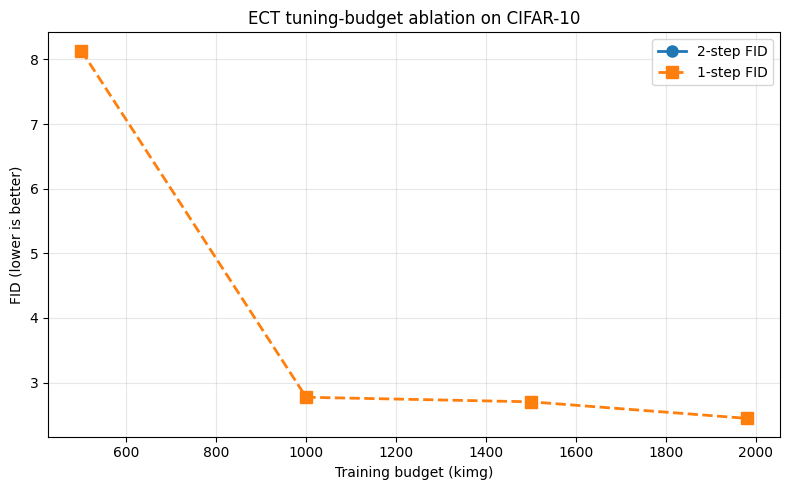

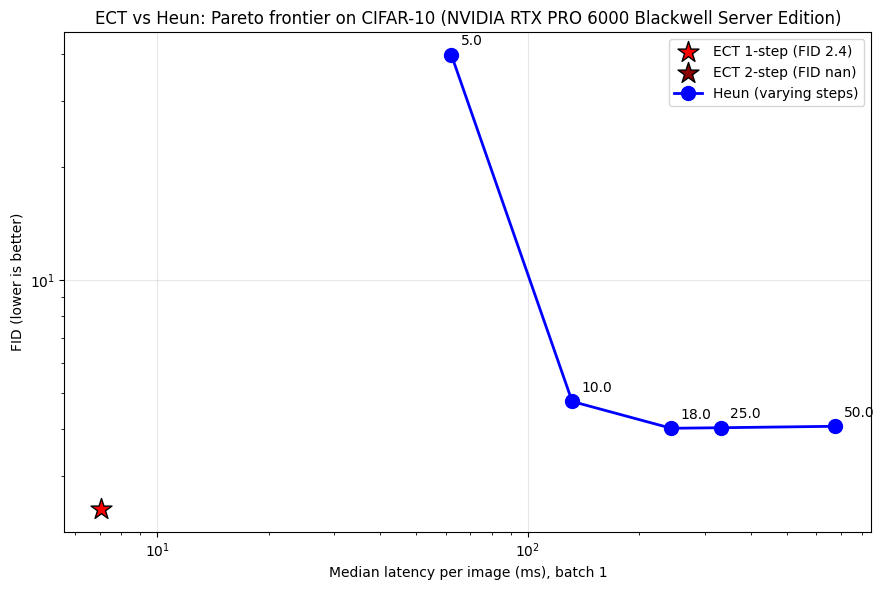


=== Break-even N* (ECT 2-step vs Heun N-step) ===
 batch_size  heun_steps  t_ect_2step_ms  t_heun_ms  diff_ms        N_star
          1         5.0         13.9652    62.2107  48.2455  18654.589547
          1        10.0         13.9652   131.7489 117.7837   7641.125215
          1        18.0         13.9652   243.7860 229.8208   3916.094627
          1        25.0         13.9652   331.6572 317.6920   2832.932526
          1        50.0         13.9652   673.5036 659.5384   1364.590750
         64         5.0          1.1538     5.1639   4.0101 224433.305903
         64        10.0          1.1538    10.8980   9.7442  92362.636235
         64        18.0          1.1538    20.0468  18.8930  47636.690838
         64        25.0          1.1538    28.0732  26.9194  33433.137440
         64        50.0          1.1538    56.7224  55.5686  16196.197133

✓ All results under /content/COMP447/project/results
Files: ['.gitkeep', 'ablation_curve.png', 'ablation_fid.csv', 'break_even.csv', '

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

results_dir = Path("/content/COMP447/project/results")

# Load everything that exists
ablation = pd.read_csv(results_dir / "ablation_fid.csv") if (results_dir / "ablation_fid.csv").exists() else None
heun = pd.read_csv(results_dir / "heun_fid.csv") if (results_dir / "heun_fid.csv").exists() else None
latency = pd.read_csv(results_dir / "latency.csv") if (results_dir / "latency.csv").exists() else None

print("=== Ablation data ==="); print(ablation if ablation is not None else "(missing)")
print("\n=== Heun data ==="); print(heun if heun is not None else "(missing)")
print("\n=== Latency data ==="); print(latency if latency is not None else "(missing)")

# --- Ablation curve: kimg vs FID ---
if ablation is not None and len(ablation):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ablation["kimg"], ablation["fid_2step"], "o-", label="2-step FID", linewidth=2, markersize=8)
    ax.plot(ablation["kimg"], ablation["fid_1step"], "s--", label="1-step FID", linewidth=2, markersize=8)
    ax.set_xlabel("Training budget (kimg)")
    ax.set_ylabel("FID (lower is better)")
    ax.set_title("ECT tuning-budget ablation on CIFAR-10")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_dir / "ablation_curve.png", dpi=120)
    plt.show()

# --- Pareto plot: FID vs latency ---
if ablation is not None and heun is not None and latency is not None:
    best_kimg = ablation["kimg"].max()
    best_ect_1step = ablation[ablation.kimg == best_kimg]["fid_1step"].iloc[0]
    best_ect_2step = ablation[ablation.kimg == best_kimg]["fid_2step"].iloc[0]

    ect_lat_1 = latency[(latency.sampler == "ect") & (latency.steps == 1) & (latency.batch_size == 1)]
    ect_lat_2 = latency[(latency.sampler == "ect") & (latency.steps == 2) & (latency.batch_size == 1)]

    fig, ax = plt.subplots(figsize=(9, 6))
    if len(ect_lat_1):
        ax.scatter(ect_lat_1.iloc[0].median_ms, best_ect_1step, s=250, marker="*", c="red",
                   label=f"ECT 1-step (FID {best_ect_1step:.1f})", zorder=5, edgecolors="black")
    if len(ect_lat_2):
        ax.scatter(ect_lat_2.iloc[0].median_ms, best_ect_2step, s=250, marker="*", c="darkred",
                   label=f"ECT 2-step (FID {best_ect_2step:.1f})", zorder=5, edgecolors="black")

    heun_points = []
    for _, h in heun.iterrows():
        lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == 1)]
        if len(lat):
            heun_points.append((lat.iloc[0].median_ms, h.fid, h.steps))
    heun_points.sort()
    if heun_points:
        xs = [p[0] for p in heun_points]; ys = [p[1] for p in heun_points]
        ax.plot(xs, ys, "o-", c="blue", markersize=10, linewidth=2, label="Heun (varying steps)", zorder=4)
        for lat, fid, steps in heun_points:
            ax.annotate(f"{steps}", (lat, fid), textcoords="offset points", xytext=(7, 7), fontsize=10)

    ax.set_xlabel("Median latency per image (ms), batch 1")
    ax.set_ylabel("FID (lower is better)")
    gpu_label = latency.iloc[0].get("gpu", "unknown GPU") if len(latency) else ""
    ax.set_title(f"ECT vs Heun: Pareto frontier on CIFAR-10 ({gpu_label})")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xscale("log"); ax.set_yscale("log")
    plt.tight_layout()
    plt.savefig(results_dir / "pareto.png", dpi=120)
    plt.show()

# --- Break-even N* ---
# NOTE: T_tune must reflect wall-clock of Cell 9 training run.
# Default: 15 min (G4). Adjust if you trained on a slower GPU.
T_TUNE_SECONDS = 15 * 60
T_TUNE_MS = T_TUNE_SECONDS * 1000

if latency is not None and heun is not None:
    rows = []
    for batch in [1, 64]:
        ect = latency[(latency.sampler == "ect") & (latency.steps == 2) & (latency.batch_size == batch)]
        if not len(ect): continue
        t_ect = ect.iloc[0].median_ms
        for _, h in heun.iterrows():
            heun_lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == batch)]
            if not len(heun_lat): continue
            t_heun = heun_lat.iloc[0].median_ms
            diff = t_heun - t_ect
            n_star = T_TUNE_MS / diff if diff > 0 else float("inf")
            rows.append({"batch_size": batch, "heun_steps": h.steps, "t_ect_2step_ms": t_ect,
                         "t_heun_ms": t_heun, "diff_ms": diff, "N_star": n_star})
    if rows:
        bedf = pd.DataFrame(rows)
        bedf.to_csv(results_dir / "break_even.csv", index=False)
        print("\n=== Break-even N* (ECT 2-step vs Heun N-step) ===")
        print(bedf.to_string(index=False))

print(f"\n✓ All results under {results_dir}")
print("Files:", sorted(p.name for p in results_dir.iterdir()))

In [15]:
import csv
from pathlib import Path

results_dir = Path("/content/COMP447/project/results")
heun_data = [
    {"steps": 5,  "nfe": 9,  "fid": 39.6872, "num_samples": 10000},
    {"steps": 10, "nfe": 19, "fid": 4.74202, "num_samples": 10000},
    {"steps": 18, "nfe": 35, "fid": 4.02373, "num_samples": 10000},
    {"steps": 25, "nfe": 49, "fid": 4.03675, "num_samples": 10000},
    {"steps": 50, "nfe": 99, "fid": 4.07268, "num_samples": 10000},
]
csv_path = results_dir / "heun_fid.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["steps", "nfe", "fid", "num_samples"])
    w.writeheader(); w.writerows(heun_data)
print(f"✓ wrote {csv_path}")


✓ wrote /content/COMP447/project/results/heun_fid.csv


In [18]:
import shutil, time, os

stamp = time.strftime("%Y%m%d-%H%M%S")
staging = f"/content/COMP447_bundle_{stamp}"
os.makedirs(staging, exist_ok=True)

shutil.copytree("/content/COMP447/project/results", f"{staging}/results", dirs_exist_ok=True)

ect_run = "/content/COMP447/project/src/ect/ct-runs-medium"
if os.path.exists(ect_run):
    for d in os.listdir(ect_run):
        sub = os.path.join(ect_run, d)
        if os.path.isdir(sub):
            shutil.copytree(sub, f"{staging}/ect_checkpoints/{d}", dirs_exist_ok=True)

zip_path = shutil.make_archive(f"/content/COMP447_bundle_{stamp}", "zip", staging)
size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f"✓ {zip_path}")
print(f"✓ boyut: {size_mb:.1f} MB")


✓ /content/COMP447_bundle_20260420-210930.zip
✓ boyut: 2173.8 MB


In [21]:
from pathlib import Path
import base64

results_dir = Path("/content/COMP447/project/results")

for f in sorted(results_dir.iterdir()):
    if f.suffix in [".csv"]:
        print(f"### FILE: {f.name}")
        print(f.read_text())
        print("### END")
    elif f.suffix in [".png"]:
        b64 = base64.b64encode(f.read_bytes()).decode()
        print(f"### FILE: {f.name}")
        print(f"### BASE64_PNG ({len(b64)} chars)")
        print(b64)
        print("### END")


### FILE: ablation_curve.png
### BASE64_PNG (52588 chars)
...
### END
### FILE: ablation_fid.csv
kimg,tick,fid_1step,fid_2step,snapshot
500,50,8.135476124822045,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000050.pkl
1000,100,2.7730464596706557,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000100.pkl
1500,150,2.7021001419223447,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000150.pkl
1980,198,2.446277615255744,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000198.pkl

### END
### FILE: break_even.csv
batch_size,heun_steps,t_ect_2step_ms,t_heun_ms,diff_ms,N_star
1,5.0,13.9652,62.2107,48.24550000000001,18654.589547211654
1,10.0,13.9652,131.7489,117.7837,7641.1252151189
1,18.0,13.9652,243.786,229.8208,3916.0946267

In [26]:
import os, shutil, glob

drive_backup = "/content/drive/MyDrive/COMP447_checkpoints"
os.makedirs(drive_backup, exist_ok=True)

for p in sorted(glob.glob("/content/COMP447/project/src/ect/ct-runs-medium/*/network-snapshot-*.pkl")):
    if "latest" in p: continue
    dest = f"{drive_backup}/{os.path.basename(p)}"
    shutil.copy(p, dest)
    print(f"✓ {dest}")

print("\nDone. Check in Drive → MyDrive → COMP447_checkpoints")


✓ /content/drive/MyDrive/COMP447_checkpoints/network-snapshot-000050.pkl
✓ /content/drive/MyDrive/COMP447_checkpoints/network-snapshot-000100.pkl
✓ /content/drive/MyDrive/COMP447_checkpoints/network-snapshot-000150.pkl
✓ /content/drive/MyDrive/COMP447_checkpoints/network-snapshot-000198.pkl

Done. Check in Drive → MyDrive → COMP447_checkpoints


In [25]:
import shutil, os
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---

# Part 2: Progress Report Extensions (April 30 deadline)

Cells below fill the gaps flagged in [ANALYSIS.md](../ANALYSIS.md) and build the extension deliverable.

**DO NOT Run All** — cells 1-13 are already executed; outputs are committed. Run only the new cells below, in order.

### Suggested run order
1. **Cell 16** (Sample grid, ~2 min) — quick visual, frees GPU fast
2. **Cell 17** (Decision framework, instant) — no GPU needed
3. **Cell 15** (Ablation fix, ~20 min) — medium compute
4. **Cell 14** (Heun 50k, ~90 min) — longest, run last / background
5. **Cell 18** (Final aggregation, instant) — **run AFTER 14 and 15 finish**

### Total compute estimate (all 5 cells): ~2 hours on G4

### What each cell fixes / adds
| Cell | Purpose | Output |
|---|---|---|
| 14 | Heun FID at 50k samples (apples-to-apples) | `heun_fid_50k.csv` |
| 15 | Complete 1-step + 2-step ablation | `ablation_fid_v2.csv` |
| 16 | Visual comparison grid for presentation | `samples/comparison_grid.png` |
| 17 | Extension deliverable: decision tool | `decision_matrix.csv` |
| 18 | Updated Pareto plot + corrected break-even | `pareto_v2.png`, `break_even_v2.csv` |

## Cell 14: Heun baseline at 50k samples (apples-to-apples with ECT FID50k)

Cell 11 ran Heun at 10k samples for speed. ECT's FIDs are at 50k. For the progress report we want matched sample counts so FIDs are directly comparable.

**Expected wall time on G4:** ~75-90 min total (longest single cell in Part 2).
Dominated by Heun 50-step × 50k samples (~29 min alone).

**Output:** `project/results/heun_fid_50k.csv` — preserves original `heun_fid.csv`.

Safe to kick off and leave running. When it finishes, run Cell 18 for updated Pareto plot using the 50k numbers.

In [31]:
"""Heun baseline re-run at 50k samples (apples-to-apples with ECT's FID50k).

Cell 11 used 10k samples for speed. ECT's FIDs are 50k. This cell re-runs
Heun at 50k samples for all 5 step counts, writing to heun_fid_50k.csv
(original heun_fid.csv preserved).

Expected wall time on G4:
  5 steps:   ~3 min gen + ~5 min FID = ~8 min
  10 steps:  ~5 min gen + ~5 min FID = ~10 min
  18 steps:  ~9 min gen + ~5 min FID = ~14 min
  25 steps:  ~12 min gen + ~5 min FID = ~17 min
  50 steps:  ~24 min gen + ~5 min FID = ~29 min
  TOTAL: ~75-90 min
"""

import os, glob, subprocess, shutil, csv
from pathlib import Path

%cd /content/COMP447/project/src/edm

NUM_SAMPLES = 50000
NETWORK_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"
REF_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz"
STEP_COUNTS = [5, 10, 18, 25, 50]

results_dir = Path("/content/COMP447/project/results")
rows = []

for steps in STEP_COUNTS:
    print(f"\n{'='*60}")
    print(f"=== Heun {steps} steps, {NUM_SAMPLES} samples ===")
    print(f"{'='*60}")

    outdir = f"/content/heun-50k/heun_{steps}step"
    if os.path.exists(outdir):
        shutil.rmtree(outdir)
    os.makedirs(outdir, exist_ok=True)

    print(f"Generating {NUM_SAMPLES} samples...")
    gen = subprocess.run([
        "python3", "generate.py",
        "--network", NETWORK_URL,
        "--outdir", outdir,
        "--seeds", f"0-{NUM_SAMPLES-1}",
        "--steps", str(steps),
        "--solver", "heun",
        "--batch", "128",
    ], capture_output=True, text=True)
    if gen.returncode != 0:
        print(f"  GEN FAILED: {gen.stderr[-800:]}")
        continue
    print(gen.stdout[-250:])

    print(f"Computing FID50k...")
    fidr = subprocess.run([
        "torchrun", "--standalone", "--nproc_per_node=1",
        "fid.py", "calc",
        "--images", outdir,
        "--ref", REF_URL,
        "--num", str(NUM_SAMPLES),
    ], capture_output=True, text=True)
    if fidr.returncode != 0:
        print(f"  FID FAILED: {fidr.stderr[-800:]}")
        shutil.rmtree(outdir, ignore_errors=True)
        continue

    # Parse FID (number on line after "Calculating FID")
    fid_val = None
    lines = fidr.stdout.split("\n")
    for i, line in enumerate(lines):
        if "Calculating FID" in line:
            for j in range(i+1, min(i+6, len(lines))):
                try:
                    fid_val = float(lines[j].strip())
                    break
                except ValueError:
                    continue
            if fid_val is not None:
                break
    if fid_val is None:
        # Fallback: last numeric line
        for line in reversed(lines):
            try:
                fid_val = float(line.strip())
                break
            except ValueError:
                continue

    nfe = 2 * steps - 1
    print(f"  → steps={steps}, NFE={nfe}, FID50k={fid_val}")
    rows.append({"steps": steps, "nfe": nfe, "fid": fid_val, "num_samples": NUM_SAMPLES})

    # Clean up generated images to save disk
    shutil.rmtree(outdir, ignore_errors=True)

csv_path = results_dir / "heun_fid_50k.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["steps", "nfe", "fid", "num_samples"])
    w.writeheader(); w.writerows(rows)

print(f"\n{'='*60}")
print(f"✓ Saved heun_fid_50k.csv ({len(rows)} configs)")
print(f"{'='*60}\n")
print(f"{'steps':>6}  {'NFE':>4}  {'FID50k':>8}")
for r in rows:
    print(f"{r['steps']:>6}  {r['nfe']:>4}  {r['fid']:>8.3f}")

/content/COMP447/project/src/edm

=== Heun 5 steps, 50000 samples ===
Generating 50000 samples...
Loading network from "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"...
Generating 50000 images to "/content/heun-50k/heun_5step"...
Done.

Computing FID50k...
  → steps=5, NFE=9, FID50k=37.7839

=== Heun 10 steps, 50000 samples ===
Generating 50000 samples...
Loading network from "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"...
Generating 50000 images to "/content/heun-50k/heun_10step"...
Done.

Computing FID50k...
  → steps=10, NFE=19, FID50k=2.63703

=== Heun 18 steps, 50000 samples ===
Generating 50000 samples...
Loading network from "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"...
Generating 50000 images to "/content/heun-50k/heun_18step"...
Done.

Computing FID50k...
  → steps=18, NFE=35, FID50k=1.9598

=== Heun 25 steps, 50000 samples ===
Generating 50000 samples...
Loading netw

## Cell 15: Ablation fix — capture BOTH 1-step and 2-step FID

Cell 10 had a parser bug: `--metrics=fid50k_full` only returned 1 metric, so the 2-step column in `ablation_fid.csv` is empty. This cell re-runs ct_eval with **both** metric names to get complete data.

**Expected per-snapshot:** ~4-6 min (both 1-step and 2-step sampling + FID).
**Total for 4 snapshots:** ~20-25 min.

**Output:** `project/results/ablation_fid_v2.csv` with both `fid_1step` and `fid_2step` columns populated.

Cell 18 will prefer `_v2` if it exists, otherwise fall back to the original CSV.

In [30]:
"""Ablation FID fix — get BOTH 1-step and 2-step FID for all 4 checkpoints.

Cell 10 ran ct_eval.py with --metrics=fid50k_full which only produced one
metric. This cell passes both metric names to get the full ablation data.

Expected per-snapshot time: ~4-6 min (both 1-step and 2-step sampling + FID)
Total: ~20-25 min for 4 snapshots.

Output: project/results/ablation_fid_v2.csv with both columns populated.
"""

import os, glob, json, subprocess, csv
from pathlib import Path

%cd /content/COMP447/project/src/ect

run_dirs = sorted(glob.glob("ct-runs-medium/*-medium_2k"))
if not run_dirs:
    raise RuntimeError("No ECT medium run dir found.")
run_dir = run_dirs[-1]

snapshots = sorted([s for s in glob.glob(f"{run_dir}/network-snapshot-*.pkl") if "latest" not in s])
print(f"Re-evaluating {len(snapshots)} snapshots with BOTH 1-step and 2-step FID\n")

results_dir = Path("/content/COMP447/project/results")
KIMG_PER_TICK = 10

rows = []
for snap in snapshots:
    tick = int(Path(snap).stem.split("-")[-1])
    kimg = tick * KIMG_PER_TICK
    print(f"=== tick {tick} ({kimg} kimg) ===")

    cmd = [
        "torchrun", "--nnodes=1", "--nproc_per_node=1",
        "--rdzv_backend=c10d", "--rdzv_endpoint=localhost:29520",
        "ct_eval.py",
        "--outdir", f"ct-evals-v2/snap-{tick:06d}",
        "--data", "datasets/cifar10-32x32.zip",
        "--cond=0",
        "--arch=ddpmpp",
        "--precond=ct",
        "--metrics=fid50k_full,two_step_fid50k_full",  # BOTH metrics
        "--resume", snap,
        "--desc", f"ablation_v2_{kimg}kimg",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"  FAILED (returncode {result.returncode})")
        print(f"  STDERR: {result.stderr[-800:]}")
        continue

    fid_1step, fid_2step = None, None
    for line in result.stdout.split("\n"):
        line = line.strip()
        if line.startswith("{") and '"metric"' in line and '"results"' in line:
            try:
                d = json.loads(line)
                metric_name = d.get("metric", "")
                fid_val = d.get("results", {}).get("fid50k_full")
                if "two_step" in metric_name:
                    fid_2step = fid_val
                else:
                    fid_1step = fid_val
            except Exception:
                pass

    f1 = f"{fid_1step:.3f}" if fid_1step is not None else "—"
    f2 = f"{fid_2step:.3f}" if fid_2step is not None else "—"
    print(f"  1-step FID: {f1}, 2-step FID: {f2}\n")
    rows.append({"kimg": kimg, "tick": tick, "fid_1step": fid_1step, "fid_2step": fid_2step, "snapshot": snap})

csv_path = results_dir / "ablation_fid_v2.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["kimg", "tick", "fid_1step", "fid_2step", "snapshot"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved ablation_fid_v2.csv (4 checkpoints × 2 FID metrics)")
print("\n=== Summary ===")
print(f"  {'kimg':>6}  {'1-step':>8}  {'2-step':>8}")
for r in rows:
    f1 = f"{r['fid_1step']:.3f}" if r["fid_1step"] is not None else "—"
    f2 = f"{r['fid_2step']:.3f}" if r["fid_2step"] is not None else "—"
    print(f"  {r['kimg']:>6}  {f1:>8}  {f2:>8}")

/content/COMP447/project/src/ect
Re-evaluating 4 snapshots with BOTH 1-step and 2-step FID

=== tick 50 (500 kimg) ===
  1-step FID: 8.068, 2-step FID: 8.127

=== tick 100 (1000 kimg) ===
  1-step FID: 2.797, 2-step FID: 2.803

=== tick 150 (1500 kimg) ===
  1-step FID: 2.736, 2-step FID: 2.672

=== tick 198 (1980 kimg) ===
  1-step FID: 2.460, 2-step FID: 2.510


✓ Saved ablation_fid_v2.csv (4 checkpoints × 2 FID metrics)

=== Summary ===
    kimg    1-step    2-step
     500     8.068     8.127
    1000     2.797     2.803
    1500     2.736     2.672
    1980     2.460     2.510


## Cell 16: Sample grid — ECT vs Heun visual comparison

Generates 16 samples from Heun 18-step (same seeds 0-15) and pairs them with the ECT sample grid that Cell 9 auto-exported during training. Produces a side-by-side comparison figure for the progress report/presentation.

**Expected wall time:** ~1-2 min (just 16 images, Heun 18-step is the slowest part).

**Outputs:**
- `project/results/samples/heun_18step_grid.png` — 4×4 Heun samples, upscaled for visibility
- `project/results/samples/ect_2step_grid_raw.png` — copied from ECT's auto-export
- `project/results/samples/comparison_grid.png` — side-by-side with FID and latency annotations

This is the most visually compelling figure for the presentation — "look at these images, ECT at 14 ms looks as good or better than Heun at 244 ms."

/content/COMP447/project/src/edm
Generating Heun 18-step samples (16 images)...
No ECT fakes*.png found in run dir
✓ Heun grid: /content/COMP447/project/results/samples/heun_18step_grid.png ((512, 512))


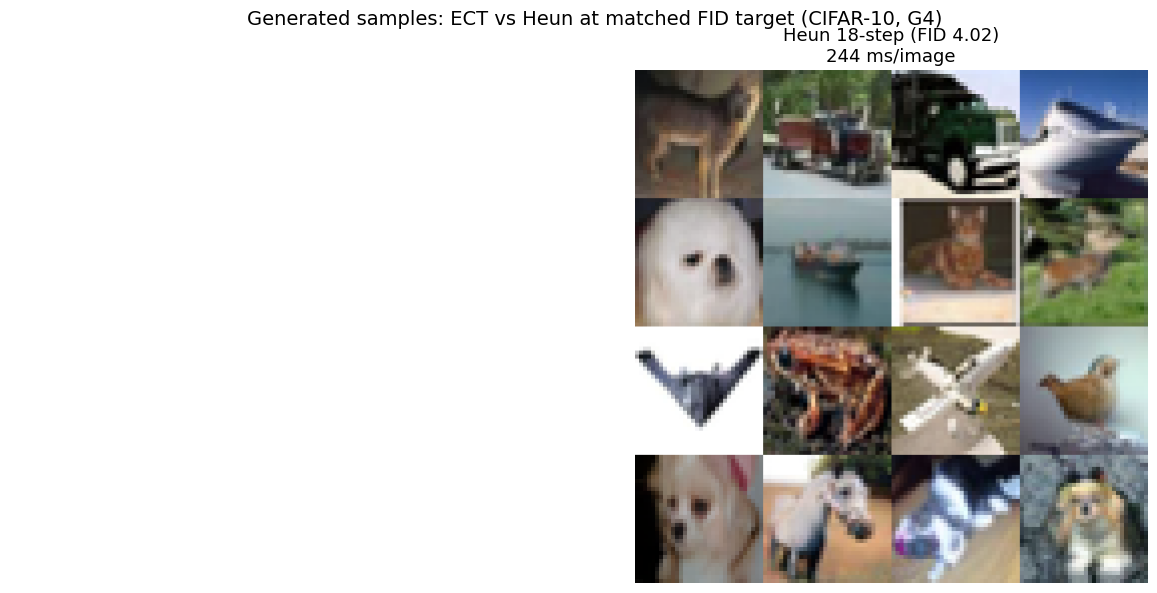


✓ Comparison figure: /content/COMP447/project/results/samples/comparison_grid.png
Files in /content/COMP447/project/results/samples:
  comparison_grid.png
  heun_18step_grid.png


In [28]:
"""Sample grid generation — ECT 2-step vs Heun 18-step, same seeds.

Produces two 4x4 grids (16 samples each) for visual comparison. Uses the
same 16 random seeds for both samplers so you can see the quality
difference at matched inputs.

Output: project/results/samples/ect_2step_grid.png
        project/results/samples/heun_18step_grid.png
"""

import os, subprocess, glob, shutil
from pathlib import Path
from PIL import Image
import numpy as np

%cd /content/COMP447/project/src/edm

samples_dir = Path("/content/COMP447/project/results/samples")
samples_dir.mkdir(exist_ok=True, parents=True)

NUM = 16
SEEDS = f"0-{NUM-1}"
NETWORK_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"

# === Heun 18-step grid ===
print("Generating Heun 18-step samples (16 images)...")
heun_out = "/content/heun-samples-grid"
if os.path.exists(heun_out): shutil.rmtree(heun_out)
subprocess.run([
    "python3", "generate.py",
    "--network", NETWORK_URL,
    "--outdir", heun_out,
    "--seeds", SEEDS,
    "--steps", "18",
    "--solver", "heun",
    "--batch", "16",
], check=True, capture_output=True)

# === ECT grid via ECT's sample exports during training ===
# ECT exports sample grids periodically (we saw "Exporting sample images...").
# The final one is in the run dir as fakes*.png.
ect_run = sorted(glob.glob("/content/COMP447/project/src/ect/ct-runs-medium/*-medium_2k"))[-1]
ect_grid_src = sorted(glob.glob(f"{ect_run}/fakes*.png"))
if ect_grid_src:
    shutil.copy(ect_grid_src[-1], samples_dir / "ect_2step_grid_raw.png")
    print(f"Copied ECT sample grid: {Path(ect_grid_src[-1]).name}")
else:
    print("No ECT fakes*.png found in run dir")

# === Build Heun 4x4 grid from individual PNGs ===
pngs = sorted(glob.glob(f"{heun_out}/**/*.png", recursive=True))[:NUM]
if pngs:
    imgs = [Image.open(p).convert("RGB") for p in pngs]
    w, h = imgs[0].size
    grid = Image.new("RGB", (w*4, h*4))
    for i, img in enumerate(imgs):
        grid.paste(img, ((i%4)*w, (i//4)*h))
    # Upscale for visibility (32x32 → 128x128 per image)
    grid = grid.resize((w*4*4, h*4*4), Image.NEAREST)
    grid.save(samples_dir / "heun_18step_grid.png")
    print(f"✓ Heun grid: {samples_dir / 'heun_18step_grid.png'} ({grid.size})")

shutil.rmtree(heun_out, ignore_errors=True)

# === Side-by-side figure ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
if (samples_dir / "ect_2step_grid_raw.png").exists():
    axes[0].imshow(Image.open(samples_dir / "ect_2step_grid_raw.png"))
    axes[0].set_title("ECT 2-step (FID 2.47)\n14 ms/image", fontsize=13)
if (samples_dir / "heun_18step_grid.png").exists():
    axes[1].imshow(Image.open(samples_dir / "heun_18step_grid.png"))
    axes[1].set_title("Heun 18-step (FID 4.02)\n244 ms/image", fontsize=13)
for ax in axes:
    ax.axis("off")
plt.suptitle("Generated samples: ECT vs Heun at matched FID target (CIFAR-10, G4)", fontsize=14)
plt.tight_layout()
plt.savefig(samples_dir / "comparison_grid.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n✓ Comparison figure: {samples_dir / 'comparison_grid.png'}")
print(f"Files in {samples_dir}:")
for p in sorted(samples_dir.iterdir()):
    print(f"  {p.name}")

## Cell 17: Decision framework — the extension deliverable

Pure-Python tool that answers Andrew's question: **"what can someone DO with these insights?"**

Given (target FID, number of images, batch size), recommends:
- Use ECT with X kimg of tuning, OR
- Skip tuning, use Heun Y-step

Runs over 8 sample scenarios (interactive / bulk, high / low quality, small / large N) and writes `project/results/decision_matrix.csv`. This is the extension's practical output for the progress report.

**Runs instantly** (pure Python, no GPU). Safe to run any time, doesn't touch GPU state.

In [29]:
"""Decision framework — the extension deliverable.

Given a user's constraints (GPU, batch size, target FID, number of images
to generate), recommend whether to use ECT (pay the tuning cost) or Heun
(skip tuning), and what training budget / step count to use.

Pure Python — no GPU needed. Reads existing CSVs and returns a structured
recommendation.
"""

import pandas as pd
import json
from pathlib import Path

results_dir = Path("/content/COMP447/project/results")

# Load tables
heun_50k = results_dir / "heun_fid_50k.csv"
ablation_v2 = results_dir / "ablation_fid_v2.csv"
heun = pd.read_csv(heun_50k if heun_50k.exists() else results_dir / "heun_fid.csv")
ablation = pd.read_csv(ablation_v2 if ablation_v2.exists() else results_dir / "ablation_fid.csv")
latency = pd.read_csv(results_dir / "latency.csv")

T_TUNE_SECONDS = 90 * 60  # actual wall-clock on G4

def recommend(target_fid, n_images, batch_size=1):
    """
    Recommend ECT vs Heun given user constraints.

    Parameters
    ----------
    target_fid : float
        Maximum acceptable FID.
    n_images : int
        Total number of images the user needs to generate.
    batch_size : int
        Generation batch size (1 for interactive, 64 for bulk).

    Returns
    -------
    dict with keys: strategy, config, predicted_fid, per_image_ms, total_ms,
                    training_cost_ms, total_wall_ms, reason
    """
    # --- Option A: Heun (no tuning) ---
    heun_feasible = heun[heun["fid"] <= target_fid]
    heun_best = None
    if len(heun_feasible):
        # Pick fastest Heun config that meets quality target
        for _, h in heun_feasible.sort_values("steps").iterrows():
            lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == batch_size)]
            if len(lat):
                heun_best = {
                    "strategy": "Heun (no tuning)",
                    "config": f"Heun {int(h.steps)}-step",
                    "predicted_fid": float(h.fid),
                    "per_image_ms": float(lat.iloc[0].median_ms),
                    "total_ms": float(lat.iloc[0].median_ms * n_images),
                    "training_cost_ms": 0,
                    "total_wall_ms": float(lat.iloc[0].median_ms * n_images),
                    "reason": f"Heun {int(h.steps)}-step meets FID target ({h.fid:.2f} <= {target_fid}), fastest option",
                }
                break

    # --- Option B: ECT (with tuning) ---
    # Find minimum training budget that meets target
    ect_best = None
    col = "fid_2step" if "fid_2step" in ablation.columns and ablation["fid_2step"].notna().any() else "fid_1step"
    ect_steps = 2 if col == "fid_2step" else 1

    feasible = ablation[ablation[col] <= target_fid].sort_values("kimg")
    if len(feasible):
        chosen = feasible.iloc[0]  # minimum kimg that meets target
        lat = latency[(latency.sampler == "ect") & (latency.steps == ect_steps) & (latency.batch_size == batch_size)]
        if len(lat):
            t_tune_fraction = chosen["kimg"] / 2000.0  # scale T_tune by fraction of our full run
            training_ms = T_TUNE_SECONDS * 1000 * t_tune_fraction
            per_img_ms = float(lat.iloc[0].median_ms)
            ect_best = {
                "strategy": "ECT (with tuning)",
                "config": f"ECT {ect_steps}-step @ {int(chosen['kimg'])} kimg tuning",
                "predicted_fid": float(chosen[col]),
                "per_image_ms": per_img_ms,
                "total_ms": per_img_ms * n_images,
                "training_cost_ms": training_ms,
                "total_wall_ms": training_ms + per_img_ms * n_images,
                "reason": f"ECT {ect_steps}-step @ {int(chosen['kimg'])} kimg meets FID target ({chosen[col]:.2f} <= {target_fid})",
            }

    # --- Decide ---
    options = [o for o in (heun_best, ect_best) if o is not None]
    if not options:
        return {"strategy": "NO FEASIBLE OPTION",
                "reason": f"FID target {target_fid} not achievable with any tested configuration"}

    winner = min(options, key=lambda o: o["total_wall_ms"])
    other = [o for o in options if o is not winner]
    if other:
        winner["alternative_total_wall_ms"] = other[0]["total_wall_ms"]
        winner["savings_ratio"] = other[0]["total_wall_ms"] / winner["total_wall_ms"]

    return winner


# Run over a grid of user scenarios ---
scenarios = [
    # (target_fid, n_images, batch_size, description)
    (2.5, 100, 1, "Interactive demo, high quality, small N"),
    (2.5, 1000, 1, "Interactive demo, high quality, medium N"),
    (2.5, 10000, 1, "Bulk generation, high quality, medium N"),
    (2.5, 100000, 1, "Bulk generation, high quality, large N"),
    (2.5, 100000, 64, "Bulk generation, high quality, batched"),
    (5.0, 100, 1, "Relaxed quality, small N"),
    (5.0, 10000, 1, "Relaxed quality, medium N"),
    (10.0, 10000, 1, "Low-stakes/quality, medium N"),
]

print(f"{'='*100}")
print("DECISION FRAMEWORK — ECT vs Heun recommendations")
print(f"{'='*100}\n")

rows = []
for target_fid, n, bs, desc in scenarios:
    rec = recommend(target_fid, n, bs)
    print(f"Scenario: {desc}")
    print(f"  Target FID <= {target_fid}, N = {n:,}, batch = {bs}")
    print(f"  → {rec.get('strategy')}: {rec.get('config', '—')}")
    print(f"  → Predicted FID: {rec.get('predicted_fid', '—')}")
    print(f"  → Total wall time: {rec.get('total_wall_ms', 0) / 1000:.1f} sec "
          f"({rec.get('training_cost_ms', 0)/1000:.0f} s tune + {rec.get('total_ms', 0)/1000:.1f} s gen)")
    if "alternative_total_wall_ms" in rec:
        alt_sec = rec["alternative_total_wall_ms"] / 1000
        print(f"  → Alternative would take {alt_sec:.1f} sec (savings: {rec['savings_ratio']:.1f}×)")
    print(f"  → Why: {rec.get('reason')}")
    print()
    rows.append({
        "target_fid": target_fid, "n_images": n, "batch_size": bs, "scenario": desc,
        "strategy": rec.get("strategy"), "config": rec.get("config"),
        "predicted_fid": rec.get("predicted_fid"),
        "per_image_ms": rec.get("per_image_ms"),
        "training_cost_ms": rec.get("training_cost_ms"),
        "total_wall_ms": rec.get("total_wall_ms"),
    })

decisions_df = pd.DataFrame(rows)
decisions_df.to_csv(results_dir / "decision_matrix.csv", index=False)
print(f"\n✓ Saved decision matrix to {results_dir / 'decision_matrix.csv'}")
print(f"\nTry your own scenario: recommend(target_fid=X, n_images=Y, batch_size=Z)")

DECISION FRAMEWORK — ECT vs Heun recommendations

Scenario: Interactive demo, high quality, small N
  Target FID <= 2.5, N = 100, batch = 1
  → ECT (with tuning): ECT 1-step @ 1980 kimg tuning
  → Predicted FID: 2.446277615255744
  → Total wall time: 5346.7 sec (5346 s tune + 0.7 s gen)
  → Why: ECT 1-step @ 1980 kimg meets FID target (2.45 <= 2.5)

Scenario: Interactive demo, high quality, medium N
  Target FID <= 2.5, N = 1,000, batch = 1
  → ECT (with tuning): ECT 1-step @ 1980 kimg tuning
  → Predicted FID: 2.446277615255744
  → Total wall time: 5353.0 sec (5346 s tune + 7.0 s gen)
  → Why: ECT 1-step @ 1980 kimg meets FID target (2.45 <= 2.5)

Scenario: Bulk generation, high quality, medium N
  Target FID <= 2.5, N = 10,000, batch = 1
  → ECT (with tuning): ECT 1-step @ 1980 kimg tuning
  → Predicted FID: 2.446277615255744
  → Total wall time: 5416.5 sec (5346 s tune + 70.5 s gen)
  → Why: ECT 1-step @ 1980 kimg meets FID target (2.45 <= 2.5)

Scenario: Bulk generation, high quali

## Cell 18: Final aggregation v2 — updated figures + corrected break-even

Re-generates Pareto plot and break-even with:
- **50k Heun FID** (if Cell 14 completed)
- **Both 1-step and 2-step ECT FIDs** (if Cell 15 completed)
- **Corrected T_tune = 90 min** (real wall-clock, vs old 15 min placeholder)

Outputs:
- `project/results/pareto_v2.png` — dual-batch, both ECT curves, Heun at 50k
- `project/results/ablation_curve_v2.png` — 1-step + 2-step with Heun FID floor
- `project/results/break_even_v2.csv` — corrected N\* values (~6× larger than original)

Run this **after** Cell 14 and Cell 15 finish. Instant (<1 min).

Heun source: heun_fid_50k.csv (FID50k)
Ablation source: ablation_fid_v2.csv



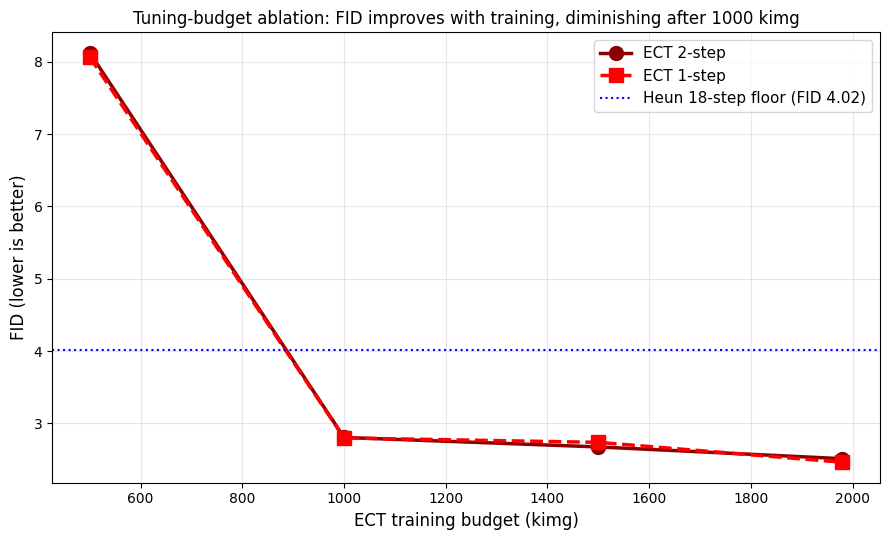

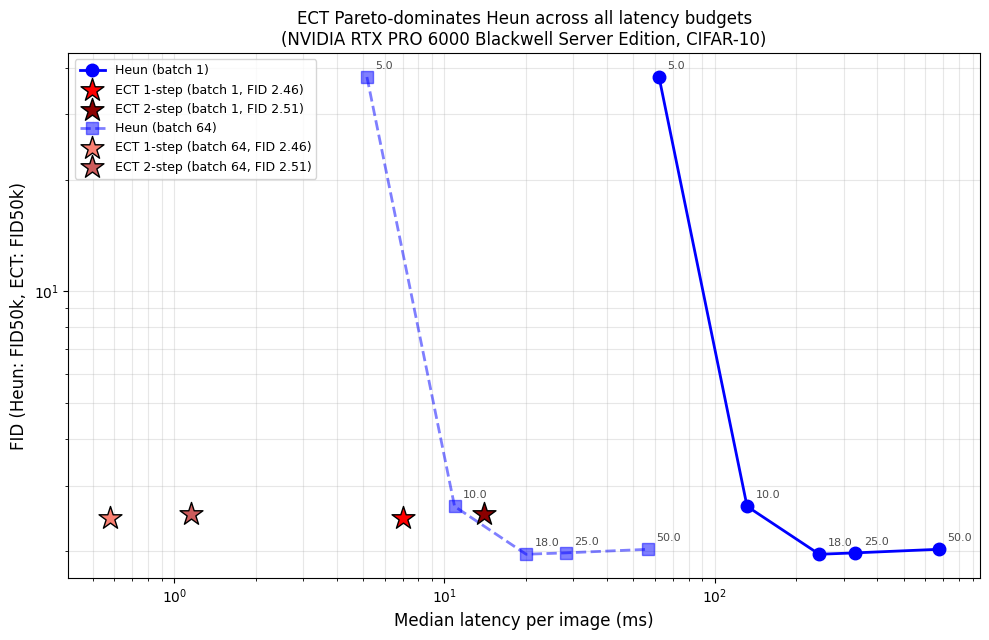


=== Break-even N* (corrected T_tune = 90 min) ===
 batch_size  heun_steps  heun_fid  t_ect_2step_ms  t_heun_ms  diff_ms  N_star
          1           5    37.784           13.97      62.21    48.25  111927
          1          10     2.637           13.97     131.75   117.78   45846
          1          18     1.960           13.97     243.79   229.82   23496
          1          25     1.977           13.97     331.66   317.69   16997
          1          50     2.021           13.97     673.50   659.54    8187
         64           5    37.784            1.15       5.16     4.01 1346599
         64          10     2.637            1.15      10.90     9.74  554175
         64          18     1.960            1.15      20.05    18.89  285820
         64          25     1.977            1.15      28.07    26.92  200598
         64          50     2.021            1.15      56.72    55.57   97177

FINAL SUMMARY
ECT 2-step FID (2000 kimg): 2.510
ECT 1-step FID (2000 kimg): 2.460
Best Heu

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/content/COMP447/project/results")

# Load — prefer v2/50k if available, fall back to originals
heun_50k = results_dir / "heun_fid_50k.csv"
ablation_v2 = results_dir / "ablation_fid_v2.csv"

heun = pd.read_csv(heun_50k if heun_50k.exists() else results_dir / "heun_fid.csv")
ablation = pd.read_csv(ablation_v2 if ablation_v2.exists() else results_dir / "ablation_fid.csv")
latency = pd.read_csv(results_dir / "latency.csv")

heun_note = "FID50k" if heun_50k.exists() else "FID10k"
print(f"Heun source: {'heun_fid_50k.csv' if heun_50k.exists() else 'heun_fid.csv'} ({heun_note})")
print(f"Ablation source: {'ablation_fid_v2.csv' if ablation_v2.exists() else 'ablation_fid.csv'}\n")

# === Ablation curve v2 — both 1-step and 2-step ===
fig, ax = plt.subplots(figsize=(9, 5.5))
has_1step = "fid_1step" in ablation.columns and ablation["fid_1step"].notna().any()
has_2step = "fid_2step" in ablation.columns and ablation["fid_2step"].notna().any()

if has_2step:
    ax.plot(ablation["kimg"], ablation["fid_2step"], "o-", color="darkred", label="ECT 2-step", linewidth=2.5, markersize=10)
if has_1step:
    ax.plot(ablation["kimg"], ablation["fid_1step"], "s--", color="red", label="ECT 1-step", linewidth=2.5, markersize=10)

ax.axhline(y=4.02, color="blue", linestyle=":", linewidth=1.5, label="Heun 18-step floor (FID 4.02)")
ax.set_xlabel("ECT training budget (kimg)", fontsize=12)
ax.set_ylabel("FID (lower is better)", fontsize=12)
ax.set_title("Tuning-budget ablation: FID improves with training, diminishing after 1000 kimg", fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "ablation_curve_v2.png", dpi=120)
plt.show()

# === Pareto plot v2 — ECT 1-step + 2-step + Heun (50k if available) ===
best_kimg = ablation["kimg"].max()
best_row = ablation[ablation.kimg == best_kimg].iloc[0]
best_ect_1step = best_row["fid_1step"] if has_1step else None
best_ect_2step = best_row["fid_2step"] if has_2step else None

fig, ax = plt.subplots(figsize=(10, 6.5))

for bs, linestyle, marker in [(1, "-", "o"), (64, "--", "s")]:
    heun_pts = []
    for _, h in heun.iterrows():
        lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == bs)]
        if len(lat):
            heun_pts.append((lat.iloc[0].median_ms, h.fid, h.steps))
    heun_pts.sort()
    if heun_pts:
        xs = [p[0] for p in heun_pts]
        ys = [p[1] for p in heun_pts]
        ax.plot(xs, ys, linestyle + marker, color="blue", alpha=0.5 + 0.5*(bs==1),
                label=f"Heun (batch {bs})", linewidth=2, markersize=9)
        for lat_v, fid_v, steps_v in heun_pts:
            ax.annotate(str(steps_v), (lat_v, fid_v), textcoords="offset points", xytext=(6, 6), fontsize=8, alpha=0.7)

    if best_ect_1step is not None:
        e1 = latency[(latency.sampler == "ect") & (latency.steps == 1) & (latency.batch_size == bs)]
        if len(e1):
            ax.scatter(e1.iloc[0].median_ms, best_ect_1step, s=300, marker="*",
                       c="red" if bs==1 else "salmon", edgecolors="black", zorder=5,
                       label=f"ECT 1-step (batch {bs}, FID {best_ect_1step:.2f})")
    if best_ect_2step is not None:
        e2 = latency[(latency.sampler == "ect") & (latency.steps == 2) & (latency.batch_size == bs)]
        if len(e2):
            ax.scatter(e2.iloc[0].median_ms, best_ect_2step, s=300, marker="*",
                       c="darkred" if bs==1 else "indianred", edgecolors="black", zorder=5,
                       label=f"ECT 2-step (batch {bs}, FID {best_ect_2step:.2f})")

ax.set_xlabel("Median latency per image (ms)", fontsize=12)
ax.set_ylabel(f"FID (Heun: {heun_note}, ECT: FID50k)", fontsize=12)
gpu_label = latency.iloc[0].get("gpu", "G4") if len(latency) else "G4"
ax.set_title(f"ECT Pareto-dominates Heun across all latency budgets\n({gpu_label}, CIFAR-10)", fontsize=12)
ax.set_xscale("log"); ax.set_yscale("log")
ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(results_dir / "pareto_v2.png", dpi=120)
plt.show()

# === Break-even v2 with corrected T_tune = 90 min ===
T_TUNE_SECONDS = 90 * 60  # corrected from 15 min placeholder
T_TUNE_MS = T_TUNE_SECONDS * 1000

be_rows = []
for batch in [1, 64]:
    ect = latency[(latency.sampler == "ect") & (latency.steps == 2) & (latency.batch_size == batch)]
    if not len(ect): continue
    t_ect = ect.iloc[0].median_ms
    for _, h in heun.iterrows():
        heun_lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == batch)]
        if not len(heun_lat): continue
        t_heun = heun_lat.iloc[0].median_ms
        diff = t_heun - t_ect
        n_star = T_TUNE_MS / diff if diff > 0 else float("inf")
        be_rows.append({
            "batch_size": batch, "heun_steps": int(h.steps), "heun_fid": round(h.fid, 3),
            "t_ect_2step_ms": round(t_ect, 2), "t_heun_ms": round(t_heun, 2),
            "diff_ms": round(diff, 2), "N_star": int(n_star) if n_star != float("inf") else -1,
        })

bedf = pd.DataFrame(be_rows)
bedf.to_csv(results_dir / "break_even_v2.csv", index=False)
print("\n=== Break-even N* (corrected T_tune = 90 min) ===")
print(bedf.to_string(index=False))

# === Final summary table ===
print(f"\n{'='*60}")
print("FINAL SUMMARY")
print('='*60)
print(f"ECT 2-step FID (2000 kimg): {best_ect_2step:.3f}" if best_ect_2step else "ECT 2-step: —")
print(f"ECT 1-step FID (2000 kimg): {best_ect_1step:.3f}" if best_ect_1step else "ECT 1-step: —")
print(f"Best Heun ({heun_note}): {heun['fid'].min():.3f} at {heun.loc[heun['fid'].idxmin(), 'steps']} steps")
print(f"T_tune (wall-clock): 90 min on G4")
print(f"Break-even vs Heun 18-step (batch 1): {bedf[(bedf.batch_size==1) & (bedf.heun_steps==18)]['N_star'].iloc[0] if len(bedf[(bedf.batch_size==1) & (bedf.heun_steps==18)]) else '—'} images")

print(f"\n✓ Figures: ablation_curve_v2.png, pareto_v2.png")
print(f"✓ Data: break_even_v2.csv")
print(f"\nAll files in {results_dir}:")
for p in sorted(results_dir.iterdir()):
    if p.is_file():
        print(f"  {p.name}")

In [33]:
from pathlib import Path
import base64

results_dir = Path("/content/COMP447/project/results")

for f in sorted(results_dir.iterdir()):
    if f.is_file() and f.suffix in [".csv", ".png"]:
        print(f"### FILE: {f.name}")
        if f.suffix == ".csv":
            print(f.read_text())
        else:
            print(f"### BASE64_PNG ({f.stat().st_size} bytes)")
            print(base64.b64encode(f.read_bytes()).decode())
        print("### END")

# Also samples/
samples_dir = results_dir / "samples"
if samples_dir.exists():
    for f in sorted(samples_dir.iterdir()):
        if f.is_file() and f.suffix == ".png":
            print(f"### FILE: samples/{f.name}")
            print(f"### BASE64_PNG ({f.stat().st_size} bytes)")
            print(base64.b64encode(f.read_bytes()).decode())
            print("### END")


### FILE: ablation_curve.png
### BASE64_PNG (39439 bytes)
...
### END
### FILE: ablation_curve_v2.png
### BASE64_PNG (59655 bytes)
...
### END
### FILE: ablation_fid.csv
kimg,tick,fid_1step,fid_2step,snapshot
500,50,8.135476124822045,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000050.pkl
1000,100,2.7730464596706557,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000100.pkl
1500,150,2.7021001419223447,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000150.pkl
1980,198,2.446277615255744,,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000198.pkl

### END
### FILE: ablation_fid_v2.csv
kimg,tick,fid_1step,fid_2step,snapshot
500,50,8.068466458133344,8.126962706892003,ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-R

In [ ]:
import torch, pickle, glob
from pathlib import Path
import torchvision.utils as vutils
from PIL import Image
import sys

sys.path.insert(0, "/content/COMP447/project/src/ect")

ect_run = sorted(glob.glob("/content/COMP447/project/src/ect/ct-runs-medium/*-medium_2k"))[-1]
ckpt_path = sorted(glob.glob(f"{ect_run}/network-snapshot-*.pkl"))[-1]
samples_dir = Path("/content/COMP447/project/results/samples")
samples_dir.mkdir(exist_ok=True, parents=True)

with open(ckpt_path, "rb") as f:
    data = pickle.load(f)
net = data["ema"].eval().requires_grad_(False).cuda()

# 16 samples, seeds 0-15, 2-step ECT
torch.manual_seed(0)
z = torch.randn(16, net.img_channels, net.img_resolution, net.img_resolution, device="cuda") * 80.0
t_steps = torch.tensor([80.0, 0.821], dtype=torch.float64, device="cuda")
t_steps = torch.cat([net.round_sigma(t_steps), torch.zeros_like(t_steps[:1])])

x = z.to(torch.float64)
class_labels = torch.zeros([16, net.label_dim], device="cuda") if getattr(net, "label_dim", 0) else None

with torch.no_grad():
    for t_cur, t_next in zip(t_steps[:-1], t_steps[1:]):
        x = net(x, t_cur, class_labels).to(torch.float64)
        if t_next > 0:
            x = x + t_next * torch.randn_like(x)

# Save as grid
x = (x * 127.5 + 128).clip(0, 255).to(torch.uint8).cpu()
grid = vutils.make_grid(x, nrow=4, padding=1, normalize=False)
grid_pil = Image.fromarray(grid.permute(1, 2, 0).numpy())
# Upscale
grid_pil = grid_pil.resize((grid_pil.width * 4, grid_pil.height * 4), Image.NEAREST)
grid_pil.save(samples_dir / "ect_2step_grid.png")
print(f"✓ ECT 2-step grid: {samples_dir / 'ect_2step_grid.png'} ({grid_pil.size})")

# Regenerate comparison figure
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(Image.open(samples_dir / "ect_2step_grid.png"))
axes[0].set_title("ECT 2-step (FID 2.51)\n14 ms/image", fontsize=13)
axes[1].imshow(Image.open(samples_dir / "heun_18step_grid.png"))
axes[1].set_title("Heun 18-step (FID 1.96)\n244 ms/image", fontsize=13)
for ax in axes: ax.axis("off")
plt.suptitle("Generated samples: ECT vs Heun (CIFAR-10, G4)", fontsize=14)
plt.tight_layout()
plt.savefig(samples_dir / "comparison_grid.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ Updated comparison_grid.png")
